In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cpu
CUDA available: False


In [2]:
!pip install -q opencv-python
!pip install -q transformers
!pip install -q accelerate
!pip install -q decord
!pip install -q einops
!pip install -q ultralytics

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.6/13.6 MB 56.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 714.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 4.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.1/58.1 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.0/91.0 kB 8.7 MB/s eta 0:00:00


In [3]:
import cv2
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm
from sklearn.metrics import classification_report, confusion_matrix

In [4]:
!wget -q --show-progress https://www.crcv.ucf.edu/data/UCF101/UCF101.rar

In [5]:
!pip install -q rarfile

In [7]:
import os

print(os.listdir("/content"))

['.config', '.ipynb_checkpoints', 'val.csv', 'sample_data']


In [8]:
!wget -O /content/UCF101.rar https://www.crcv.ucf.edu/data/UCF101/UCF101.rar

--2026-09-28 04:57:26--  https://www.crcv.ucf.edu/data/UCF101/UCF101.rar
Resolving www.crcv.ucf.edu (www.crcv.ucf.edu)... 132.170.214.127
Connecting to www.crcv.ucf.edu (www.crcv.ucf.edu)|132.170.214.127|:443... connected.
ERROR: cannot verify www.crcv.ucf.edu's certificate, issued by ‘CN=InCommon RSA OV SSL CA 3,O=InCommon\\, LLC,C=US’:
  Unable to locally verify the issuer's authority.
To connect to www.crcv.ucf.edu insecurely, use `--no-check-certificate'.


In [9]:
import os

print("File exists:", os.path.exists("/content/UCF101.rar"))

if os.path.exists("/content/UCF101.rar"):
    print("File size:",
          round(os.path.getsize("/content/UCF101.rar") / (1024**2), 2),
          "MB")

File exists: True
File size: 0.0 MB


In [10]:
!pip install -q rarfile

In [13]:
from google.colab import drive

drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [14]:
import os

print(os.listdir('/content/drive/MyDrive'))

['Colab Notebooks', 'Classroom', 'IMG-20250910-WA0001.jpg', 'IMG-20260206-WA0000.jpg', 'mproject', 'H:', 'Untitled document (5).gdoc', 'Reinforcement Learning (RL).pdf', 'enrolment data.xlsx', 'Edusat Registrations.pdf', 'Student_enters_metaverse_classroom_68b33a95a0.mp4', 'AV Certificate', 'AV Certificate.gslides', 'AV Certificate.gsheet', 'Black and White Minimalist Accountant Resume.pdf', 'colour theory.gdoc', 'AI in Workspace.gdoc', 'BitBrain (1).pptx', 'mongodb.gdoc', 'Tab.gdoc', 'Assessment.gform', 'Course Registration Form   (File responses)', 'Course Registration Form .gsheet', 'Course Registration Form  .gform', 'REPORT ON CANVAS LMS AND AI TOOLS IN EDUCATION.gdoc', 'Big Data Lab Questions.gdoc', 'Document from Mowshika Srivarshini (1).pdf', 'Document from Mowshika Srivarshini.pdf', 'Project Plan.gdoc', 'Untitled document (4).gdoc', 'Software - pattern Analysis Tool kit.gdoc', 'Mowshika - Day 23 [17 06 2026].gdoc', 'Professional_C_and_NET_2021_Edition_2022_Christian_Nagel.pdf'

In [16]:
print(os.listdir('/content/drive/MyDrive/UCF101'))

['test.csv', 'train.csv', 'val.csv', 'test', 'train', 'val']


In [17]:
DATASET_PATH = '/content/drive/MyDrive/UCF101'

print("Dataset path:")
print(DATASET_PATH)

Dataset path:
/content/drive/MyDrive/UCF101


In [18]:
import os

print("Dataset exists:", os.path.exists(DATASET_PATH))

Dataset exists: True


In [19]:
classes = sorted(os.listdir(DATASET_PATH))

print("Total classes:", len(classes))
print("\nFirst 20 classes:")

for c in classes[:20]:
    print(c)

Total classes: 6

First 20 classes:
test
test.csv
train
train.csv
val
val.csv


In [20]:
SPORTS_CLASSES = [
    "Basketball",
    "BasketballDunk",
    "BaseballPitch",
    "CricketBowling",
    "CricketShot",
    "Diving",
    "GolfSwing",
    "HorseRiding",
    "SoccerPenalty",
    "TennisSwing",
    "VolleyballSpiking",
    "Skiing",
    "Surfing",
    "SkateBoarding",
    "TableTennisShot"
]

In [21]:
for sport in SPORTS_CLASSES:

    path = os.path.join(DATASET_PATH, sport)

    if os.path.exists(path):
        print("✓", sport)
    else:
        print("✗", sport, "NOT FOUND")

✗ Basketball NOT FOUND
✗ BasketballDunk NOT FOUND
✗ BaseballPitch NOT FOUND
✗ CricketBowling NOT FOUND
✗ CricketShot NOT FOUND
✗ Diving NOT FOUND
✗ GolfSwing NOT FOUND
✗ HorseRiding NOT FOUND
✗ SoccerPenalty NOT FOUND
✗ TennisSwing NOT FOUND
✗ VolleyballSpiking NOT FOUND
✗ Skiing NOT FOUND
✗ Surfing NOT FOUND
✗ SkateBoarding NOT FOUND
✗ TableTennisShot NOT FOUND


In [22]:
import os

DATASET_PATH = "/content/drive/MyDrive/UCF101"

print("Contents of UCF101:")
for item in os.listdir(DATASET_PATH):
    print(item)

Contents of UCF101:
test.csv
train.csv
val.csv
test
train
val


In [23]:
import os

TRAIN_PATH = "/content/drive/MyDrive/UCF101/train"

print("Train contents:")
print(os.listdir(TRAIN_PATH)[:30])

Train contents:
['WritingOnBoard', 'YoYo', 'WallPushups', 'WalkingWithDog', 'VolleyballSpiking', 'Typing', 'TrampolineJumping', 'UnevenBars', 'TennisSwing', 'TaiChi', 'ThrowDiscus', 'SoccerJuggling', 'SumoWrestling', 'Swing', 'TableTennisShot', 'StillRings', 'Surfing', 'SkyDiving', 'SoccerPenalty', 'Skiing', 'Skijet', 'ShavingBeard', 'SkateBoarding', 'Shotput', 'SalsaSpin', 'RopeClimbing', 'Rowing', 'PushUps', 'PommelHorse', 'Punch']


In [24]:
import os

DATASET_PATH = "/content/drive/MyDrive/UCF101"

TRAIN_PATH = os.path.join(DATASET_PATH, "train")
VAL_PATH = os.path.join(DATASET_PATH, "val")
TEST_PATH = os.path.join(DATASET_PATH, "test")

SPORTS_CLASSES = [
    "Basketball",
    "BasketballDunk",
    "BaseballPitch",
    "CricketBowling",
    "CricketShot",
    "Diving",
    "GolfSwing",
    "HorseRiding",
    "SoccerPenalty",
    "TennisSwing",
    "VolleyballSpiking",
    "Skiing",
    "Surfing",
    "SkateBoarding",
    "TableTennisShot"
]

print("Checking sports classes...\n")

for sport in SPORTS_CLASSES:
    path = os.path.join(TRAIN_PATH, sport)

    if os.path.exists(path):
        print("✓", sport)
    else:
        print("✗", sport)

Checking sports classes...

✓ Basketball
✓ BasketballDunk
✓ BaseballPitch
✓ CricketBowling
✓ CricketShot
✓ Diving
✓ GolfSwing
✓ HorseRiding
✓ SoccerPenalty
✓ TennisSwing
✓ VolleyballSpiking
✓ Skiing
✓ Surfing
✓ SkateBoarding
✓ TableTennisShot


In [25]:
from collections import Counter

for split_name, split_path in [
    ("Train", TRAIN_PATH),
    ("Validation", VAL_PATH),
    ("Test", TEST_PATH)
]:

    print(f"\n===== {split_name} =====")

    total = 0

    for sport in SPORTS_CLASSES:

        class_path = os.path.join(split_path, sport)

        if os.path.exists(class_path):

            videos = [
                f for f in os.listdir(class_path)
                if f.lower().endswith((".avi", ".mp4", ".mov", ".mkv"))
            ]

            print(f"{sport:20s}: {len(videos)}")

            total += len(videos)

    print("Total:", total)


===== Train =====
Basketball          : 198
BasketballDunk      : 98
BaseballPitch       : 112
CricketBowling      : 104
CricketShot         : 125
Diving              : 112
GolfSwing           : 104
HorseRiding         : 123
SoccerPenalty       : 102
TennisSwing         : 124
VolleyballSpiking   : 87
Skiing              : 101
Surfing             : 94
SkateBoarding       : 90
TableTennisShot     : 105
Total: 1679

===== Validation =====
Basketball          : 33
BasketballDunk      : 16
BaseballPitch       : 19
CricketBowling      : 17
CricketShot         : 21
Diving              : 19
GolfSwing           : 17
HorseRiding         : 20
SoccerPenalty       : 17
TennisSwing         : 21
VolleyballSpiking   : 14
Skiing              : 17
Surfing             : 16
SkateBoarding       : 15
TableTennisShot     : 17
Total: 279

===== Test =====
Basketball          : 34
BasketballDunk      : 17
BaseballPitch       : 19
CricketBowling      : 18
CricketShot         : 21
Diving              : 19
GolfS

In [26]:
import cv2
import matplotlib.pyplot as plt

sport = "Basketball"

class_path = os.path.join(
    TRAIN_PATH,
    sport
)

video_files = [
    f for f in os.listdir(class_path)
    if f.lower().endswith(".avi")
]

print("Number of videos:", len(video_files))

video_path = os.path.join(
    class_path,
    video_files[0]
)

print("Testing:", video_path)

Number of videos: 198
Testing: /content/drive/MyDrive/UCF101/train/Basketball/v_BasketballDunk_g01_c01.avi


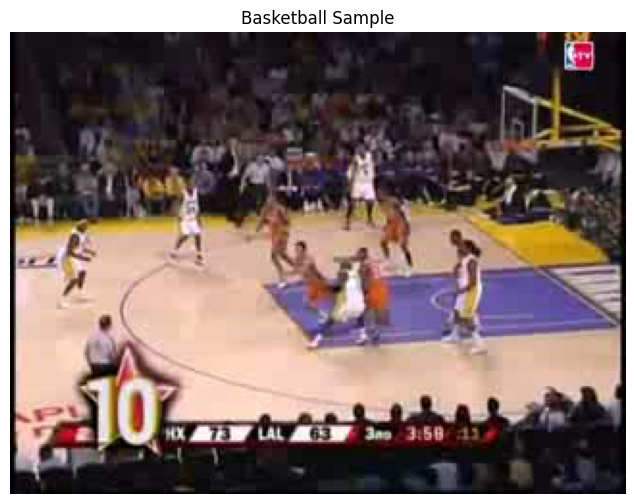

In [27]:
cap = cv2.VideoCapture(video_path)

ret, frame = cap.read()

cap.release()

if ret:

    frame = cv2.cvtColor(
        frame,
        cv2.COLOR_BGR2RGB
    )

    plt.figure(figsize=(8, 6))
    plt.imshow(frame)
    plt.axis("off")
    plt.title("Basketball Sample")
    plt.show()

else:

    print("ERROR: Could not read video")

In [28]:
import numpy as np
import cv2

def extract_frames(video_path, num_frames=16):

    cap = cv2.VideoCapture(video_path)

    total_frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    if total_frames <= 0:
        cap.release()
        return []

    frame_indices = np.linspace(
        0,
        total_frames - 1,
        num_frames
    ).astype(int)

    frames = []

    for index in frame_indices:

        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            index
        )

        ret, frame = cap.read()

        if ret:

            frame = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB
            )

            frames.append(frame)

    cap.release()

    return frames

In [29]:
frames = extract_frames(
    video_path,
    num_frames=16
)

print("Frames extracted:", len(frames))

Frames extracted: 16


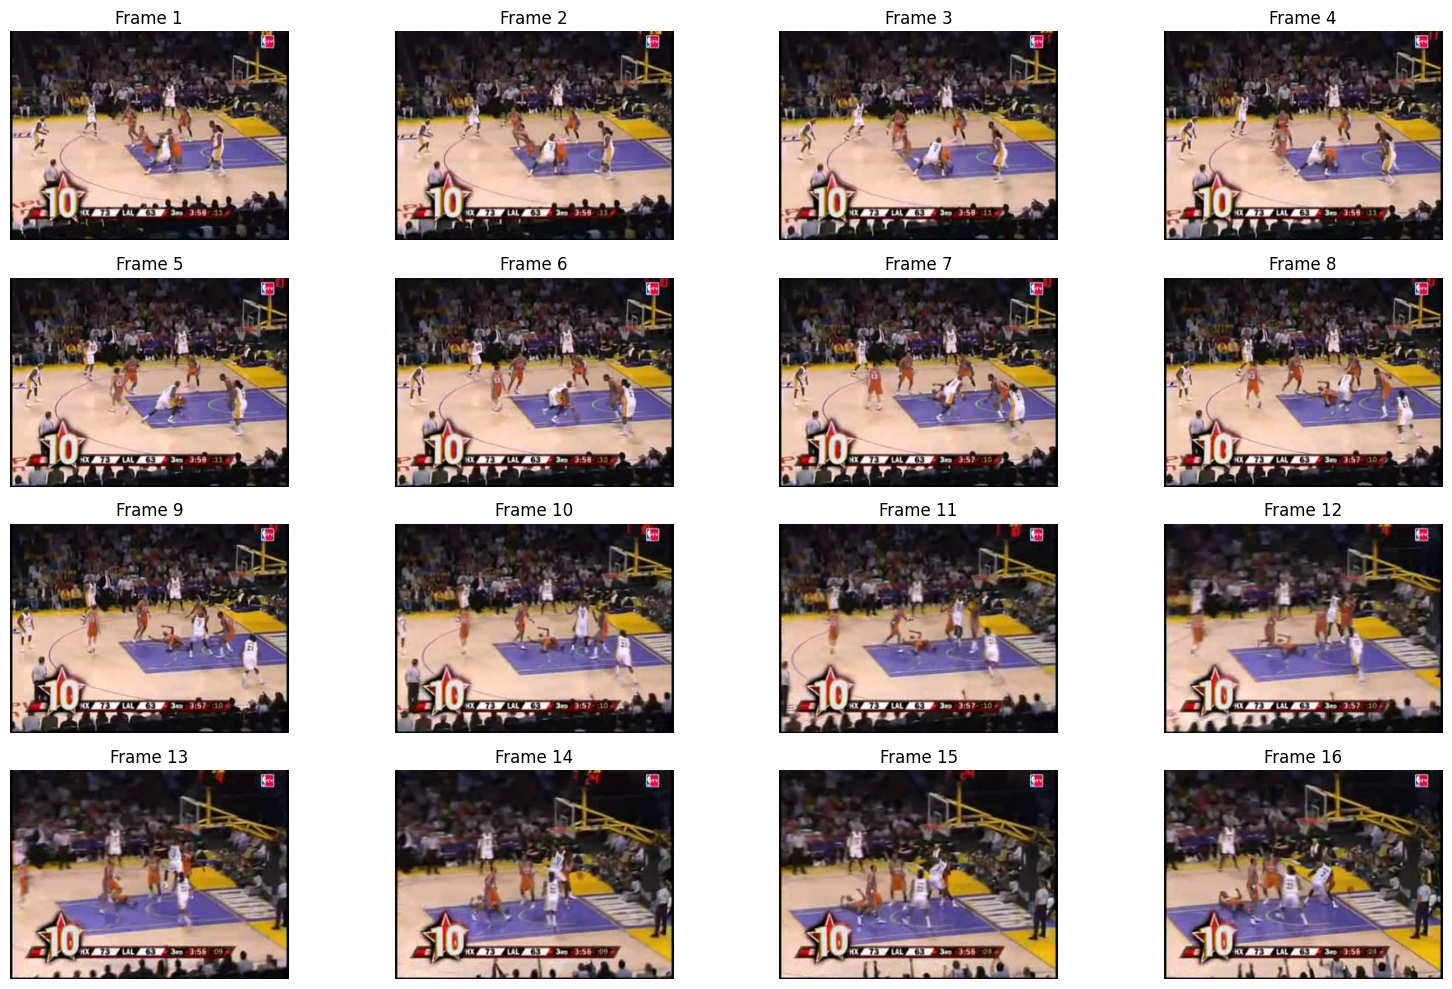

In [30]:
plt.figure(figsize=(16, 10))

for i, frame in enumerate(frames):

    plt.subplot(4, 4, i + 1)

    plt.imshow(frame)

    plt.axis("off")

    plt.title(f"Frame {i + 1}")

plt.tight_layout()
plt.show()

In [1]:
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch: 2.11.0+cu128
CUDA available: True
GPU: Tesla T4


In [16]:
!pip install -q torch torchvision opencv-python pandas numpy scikit-learn matplotlib tqdm

In [17]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
import matplotlib.pyplot as plt
from tqdm import tqdm

In [18]:
DATASET_PATH = "/content/drive/MyDrive/UCF101"

TRAIN_PATH = os.path.join(DATASET_PATH, "train")
VAL_PATH = os.path.join(DATASET_PATH, "val")
TEST_PATH = os.path.join(DATASET_PATH, "test")

print("Train:", TRAIN_PATH)
print("Validation:", VAL_PATH)
print("Test:", TEST_PATH)

Train: /content/drive/MyDrive/UCF101/train
Validation: /content/drive/MyDrive/UCF101/val
Test: /content/drive/MyDrive/UCF101/test


In [19]:
SPORTS_CLASSES = [
    "Basketball",
    "BasketballDunk",
    "BaseballPitch",
    "CricketBowling",
    "CricketShot",
    "Diving",
    "GolfSwing",
    "HorseRiding",
    "SoccerPenalty",
    "TennisSwing",
    "VolleyballSpiking",
    "Skiing",
    "Surfing",
    "SkateBoarding",
    "TableTennisShot"
]

print("Number of classes:", len(SPORTS_CLASSES))

Number of classes: 15


In [20]:
class_to_idx = {
    class_name: idx
    for idx, class_name in enumerate(SPORTS_CLASSES)
}

idx_to_class = {
    idx: class_name
    for class_name, idx in class_to_idx.items()
}

print(class_to_idx)

{'Basketball': 0, 'BasketballDunk': 1, 'BaseballPitch': 2, 'CricketBowling': 3, 'CricketShot': 4, 'Diving': 5, 'GolfSwing': 6, 'HorseRiding': 7, 'SoccerPenalty': 8, 'TennisSwing': 9, 'VolleyballSpiking': 10, 'Skiing': 11, 'Surfing': 12, 'SkateBoarding': 13, 'TableTennisShot': 14}


Create the video dataset

This is the most important cell for this stage.

In [21]:
class SportsVideoDataset(Dataset):

    def __init__(
        self,
        root_dir,
        classes,
        num_frames=16,
        image_size=112
    ):
        self.root_dir = root_dir
        self.classes = classes
        self.num_frames = num_frames
        self.image_size = image_size

        self.class_to_idx = {
            class_name: idx
            for idx, class_name in enumerate(classes)
        }

        self.video_files = []

        # Find videos
        for class_name in classes:

            class_path = os.path.join(root_dir, class_name)

            if not os.path.exists(class_path):
                print("Warning: class not found:", class_name)
                continue

            for file_name in os.listdir(class_path):

                if file_name.lower().endswith(
                    (".avi", ".mp4", ".mov", ".mkv")
                ):

                    video_path = os.path.join(
                        class_path,
                        file_name
                    )

                    label = self.class_to_idx[class_name]

                    self.video_files.append(
                        (video_path, label)
                    )

        print(
            f"Found {len(self.video_files)} videos in {root_dir}"
        )

    def __len__(self):
        return len(self.video_files)

    def __getitem__(self, index):

        video_path, label = self.video_files[index]

        frames = self.load_video(video_path)

        # Convert:
        # [T, H, W, C]
        # to
        # [C, T, H, W]

        frames = np.transpose(
            frames,
            (3, 0, 1, 2)
        )

        frames = torch.tensor(
            frames,
            dtype=torch.float32
        )

        # Normalize 0-255 → 0-1
        frames = frames / 255.0

        # ImageNet/Kinetics-style normalization
        mean = torch.tensor(
            [0.43216, 0.394666, 0.37645]
        ).view(3, 1, 1, 1)

        std = torch.tensor(
            [0.22803, 0.22145, 0.216989]
        ).view(3, 1, 1, 1)

        frames = (frames - mean) / std

        return frames, torch.tensor(
            label,
            dtype=torch.long
        )

    def load_video(self, video_path):

        cap = cv2.VideoCapture(video_path)

        total_frames = int(
            cap.get(cv2.CAP_PROP_FRAME_COUNT)
        )

        if total_frames <= 0:
            cap.release()

            raise RuntimeError(
                f"Could not read video: {video_path}"
            )

        # Select equally spaced frames
        frame_indices = np.linspace(
            0,
            total_frames - 1,
            self.num_frames
        ).astype(int)

        frames = []

        for frame_index in frame_indices:

            cap.set(
                cv2.CAP_PROP_POS_FRAMES,
                int(frame_index)
            )

            success, frame = cap.read()

            if success:

                frame = cv2.cvtColor(
                    frame,
                    cv2.COLOR_BGR2RGB
                )

                frame = cv2.resize(
                    frame,
                    (
                        self.image_size,
                        self.image_size
                    )
                )

                frames.append(frame)

        cap.release()

        # If some frames failed,
        # repeat the last valid frame

        if len(frames) == 0:

            raise RuntimeError(
                f"No frames could be read: {video_path}"
            )

        while len(frames) < self.num_frames:

            frames.append(frames[-1].copy())

        frames = frames[:self.num_frames]

        return np.array(frames)

Create the training dataset

In [22]:
train_dataset = SportsVideoDataset(
    root_dir=TRAIN_PATH,
    classes=SPORTS_CLASSES,
    num_frames=16,
    image_size=112
)

Found 1679 videos in /content/drive/MyDrive/UCF101/train


Create validation and test datasets

In [23]:
val_dataset = SportsVideoDataset(
    root_dir=VAL_PATH,
    classes=SPORTS_CLASSES,
    num_frames=16,
    image_size=112
)

test_dataset = SportsVideoDataset(
    root_dir=TEST_PATH,
    classes=SPORTS_CLASSES,
    num_frames=16,
    image_size=112
)

Found 279 videos in /content/drive/MyDrive/UCF101/val
Found 287 videos in /content/drive/MyDrive/UCF101/test


Test one video

Before creating a DataLoader, let's make sure the dataset works.

In [24]:
frames, label = train_dataset[0]

print("Frame tensor shape:", frames.shape)
print("Label:", label.item())
print("Class:", idx_to_class[label.item()])

Frame tensor shape: torch.Size([3, 16, 112, 112])
Label: 0
Class: Basketball


Expected:

Frame tensor shape: torch.Size([3, 16, 112, 112])
Label: 0
Class: Basketball

The important part is:

[3, 16, 112, 112]

This means:

3     → RGB channels
16    → video frames
112   → height
112   → width

Create DataLoaders

Now we batch the videos for the neural network.

In [25]:
BATCH_SIZE = 4

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

Test one batch

In [26]:
videos, labels = next(iter(train_loader))

print("Video batch shape:", videos.shape)
print("Labels shape:", labels.shape)
print("Labels:", labels)

Video batch shape: torch.Size([4, 3, 16, 112, 112])
Labels shape: torch.Size([4])
Labels: tensor([3, 9, 3, 8])


Check the actual classes in the batch

In [27]:
for label in labels:

    print(
        label.item(),
        "→",
        idx_to_class[label.item()]
    )

3 → CricketBowling
9 → TennisSwing
3 → CricketBowling
8 → SoccerPenalty


Check GPU

Before we build the deep-learning model:

In [28]:
device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Device: cuda
GPU: Tesla T4


Video
 ↓
16 frames
 ↓
PyTorch Dataset
 ↓
DataLoader

Step 1 — Import the 3D CNN model

In [29]:
import torch
import torch.nn as nn
from torchvision.models.video import r3d_18, R3D_18_Weights

print("PyTorch:", torch.__version__)

PyTorch: 2.11.0+cu128


Step 2 — Load the pretrained R3D-18 model

In [30]:
weights = R3D_18_Weights.DEFAULT

model = r3d_18(weights=weights)

print(model)

Downloading: "https://download.pytorch.org/models/r3d_18-b3b3357e.pth" to /root/.cache/torch/hub/checkpoints/r3d_18-b3b3357e.pth


100%|██████████| 127M/127M [00:00<00:00, 201MB/s]


VideoResNet(
  (stem): BasicStem(
    (0): Conv3d(3, 64, kernel_size=(3, 7, 7), stride=(1, 2, 2), padding=(1, 3, 3), bias=False)
    (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
  )
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Sequential(
        (0): Conv3DSimple(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        (2): ReLU(inplace=True)
      )
      (conv2): Sequential(
        (0): Conv3DSimple(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        (1): BatchNorm3d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (relu): ReLU(inplace=True)
    )
    (1): BasicBlock(
      (conv1): Sequential(
        (0): Conv3DSimple(64, 64, kernel_size=(3, 3, 3), stride=(1, 1, 1), padding=(1, 1, 1), bias=False)
        (1):

Step 3 — Replace the final classification layer

In [31]:
print(model.fc)

Linear(in_features=512, out_features=400, bias=True)


In [32]:
NUM_CLASSES = len(SPORTS_CLASSES)

model.fc = nn.Linear(
    model.fc.in_features,
    NUM_CLASSES
)

print(model.fc)

Linear(in_features=512, out_features=15, bias=True)


Step 4 — Move the model to GPU

In [33]:
model = model.to(device)

print("Model is running on:", device)

Model is running on: cuda


Step 5 — Freeze the pretrained layers initially

In [34]:
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

In [35]:
trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

print("Trainable parameters:", trainable_params)
print("Total parameters:", total_params)

Trainable parameters: 7695
Total parameters: 33173967


Step 6 — Define the loss function

In [36]:
criterion = nn.CrossEntropyLoss()

Step 7 — Define the optimizer

In [37]:
optimizer = torch.optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

Step 8 — Create the training function

In [38]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(
        loader,
        desc="Training"
    )

    for videos, labels in progress_bar:

        videos = videos.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(videos)

        # Calculate loss
        loss = criterion(
            outputs,
            labels
        )

        # Backpropagation
        loss.backward()

        # Update model
        optimizer.step()

        # Statistics
        running_loss += loss.item()

        _, predicted = torch.max(
            outputs,
            1
        )

        total += labels.size(0)

        correct += (
            predicted == labels
        ).sum().item()

        accuracy = 100 * correct / total

        progress_bar.set_postfix(
            loss=loss.item(),
            accuracy=f"{accuracy:.2f}%"
        )

    epoch_loss = running_loss / len(loader)

    epoch_accuracy = (
        100 * correct / total
    )

    return epoch_loss, epoch_accuracy

Step 9 — Create validation function

In [39]:
def validate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        progress_bar = tqdm(
            loader,
            desc="Validation"
        )

        for videos, labels in progress_bar:

            videos = videos.to(
                device,
                non_blocking=True
            )

            labels = labels.to(
                device,
                non_blocking=True
            )

            outputs = model(videos)

            loss = criterion(
                outputs,
                labels
            )

            running_loss += loss.item()

            _, predicted = torch.max(
                outputs,
                1
            )

            total += labels.size(0)

            correct += (
                predicted == labels
            ).sum().item()

            accuracy = (
                100 * correct / total
            )

            progress_bar.set_postfix(
                loss=loss.item(),
                accuracy=f"{accuracy:.2f}%"
            )

    epoch_loss = (
        running_loss / len(loader)
    )

    epoch_accuracy = (
        100 * correct / total
    )

    return epoch_loss, epoch_accuracy

Step 10 — Train the model

Start with only 5 epochs first.

In [40]:
NUM_EPOCHS = 5

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_accuracy = 0.0

In [41]:
NUM_EPOCHS = 5

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_accuracy = 0.0

print("Training setup completed")
print("Number of epochs:", NUM_EPOCHS)

Training setup completed
Number of epochs: 5


In [42]:
def train_one_epoch(
    model,
    loader,
    criterion,
    optimizer,
    device
):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Training")

    for videos, labels in progress_bar:

        videos = videos.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        # Clear previous gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(videos)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update weights
        optimizer.step()

        # Calculate statistics
        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)

        correct += (predicted == labels).sum().item()

        accuracy = 100 * correct / total

        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            accuracy=f"{accuracy:.2f}%"
        )

    epoch_loss = running_loss / len(loader)

    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [43]:
def validate(
    model,
    loader,
    criterion,
    device
):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    progress_bar = tqdm(loader, desc="Validation")

    with torch.no_grad():

        for videos, labels in progress_bar:

            videos = videos.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(videos)

            loss = criterion(outputs, labels)

            running_loss += loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)

            correct += (predicted == labels).sum().item()

            accuracy = 100 * correct / total

            progress_bar.set_postfix(
                loss=f"{loss.item():.4f}",
                accuracy=f"{accuracy:.2f}%"
            )

    epoch_loss = running_loss / len(loader)

    epoch_accuracy = 100 * correct / total

    return epoch_loss, epoch_accuracy

In [44]:
print(train_one_epoch)
print(validate)

<function train_one_epoch at 0x7d6afe225800>
<function validate at 0x7d6afe2256c0>


In [45]:
NUM_EPOCHS = 5

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_accuracy = 0.0

print("Training setup completed")
print("Number of epochs:", NUM_EPOCHS)

Training setup completed
Number of epochs: 5


In [46]:
for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    print("-" * 50)

    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_accuracy = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_accuracy)

    val_losses.append(val_loss)
    val_accuracies.append(val_accuracy)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_accuracy:.2f}%")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_accuracy:.2f}%")

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        torch.save(
            model.state_dict(),
            "/content/best_sports_model.pth"
        )

        print("✓ Best model saved!")


Epoch 1/5
--------------------------------------------------


Validation: 100%|██████████| 70/70 [01:03<00:00,  1.11it/s, accuracy=86.74%, loss=0.0522]


Train Loss: 1.5055
Train Accuracy: 56.88%
Validation Loss: 0.4531
Validation Accuracy: 86.74%
✓ Best model saved!

Epoch 2/5
--------------------------------------------------


Validation: 100%|██████████| 70/70 [00:26<00:00,  2.61it/s, accuracy=89.96%, loss=0.0059]


Train Loss: 0.7036
Train Accuracy: 79.21%
Validation Loss: 0.3106
Validation Accuracy: 89.96%
✓ Best model saved!

Epoch 3/5
--------------------------------------------------


...

Train Loss: 0.5699
Train Accuracy: 81.72%
Validation Loss: 0.2772
Validation Accuracy: 89.25%

Epoch 4/5
--------------------------------------------------


Validation: 100%|██████████| 70/70 [00:27<00:00,  2.59it/s, accuracy=90.68%, loss=0.0010]


Train Loss: 0.5075
Train Accuracy: 83.68%
Validation Loss: 0.2247
Validation Accuracy: 90.68%
✓ Best model saved!

Epoch 5/5
--------------------------------------------------


Validation: 100%|██████████| 70/70 [00:25<00:00,  2.74it/s, accuracy=88.89%, loss=0.0003]

Train Loss: 0.4865
Train Accuracy: 82.37%
Validation Loss: 0.2426
Validation Accuracy: 88.89%


Step 11 — Plot training performance

Once training finishes:

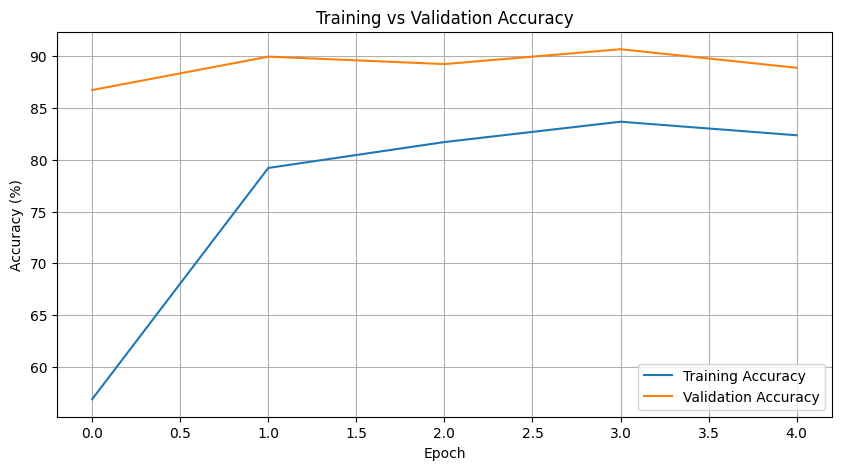

In [47]:
plt.figure(figsize=(10, 5))

plt.plot(
    train_accuracies,
    label="Training Accuracy"
)

plt.plot(
    val_accuracies,
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

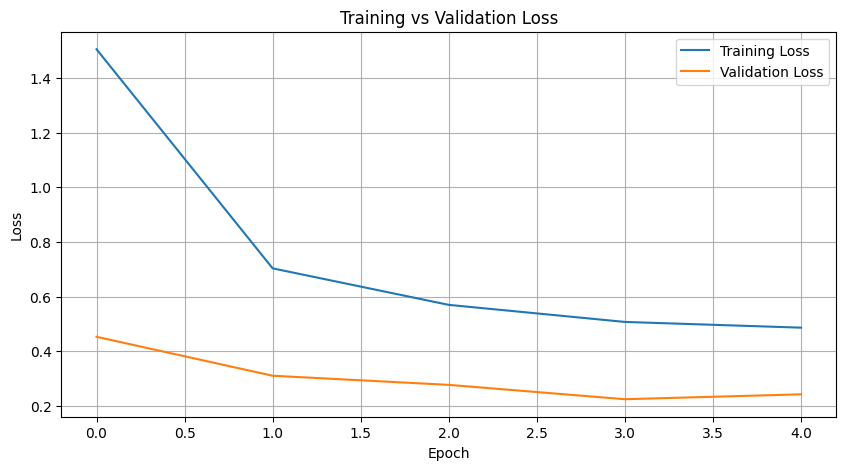

In [48]:
plt.figure(figsize=(10, 5))

plt.plot(
    train_losses,
    label="Training Loss"
)

plt.plot(
    val_losses,
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid()

plt.show()

In [49]:
SPORTS_CLASSES = [
    "Basketball",
    "BasketballDunk",
    "BaseballPitch",
    "CricketBowling",
    "CricketShot",
    "Diving",
    "GolfSwing",
    "HorseRiding",
    "SoccerPenalty",
    "TennisSwing",
    "VolleyballSpiking",
    "Skiing",
    "Surfing",
    "SkateBoarding",
    "TableTennisShot"
]

In [50]:
!pip install -q gradio

In [51]:
import gradio as gr
import torch
import cv2
import numpy as np
import os

In [52]:
from torchvision.models.video import r3d_18
import torch.nn as nn

# Create the model architecture
model = r3d_18(weights=None)

# Replace final layer with our 15 classes
model.fc = nn.Linear(
    model.fc.in_features,
    len(SPORTS_CLASSES)
)

# Load trained weights
model.load_state_dict(
    torch.load(
        "/content/best_sports_model.pth",
        map_location=device
    )
)

model = model.to(device)

model.eval()

print("✓ Trained sports model loaded")

✓ Trained sports model loaded


In [53]:
def extract_video_frames(
    video_path,
    num_frames=16,
    image_size=112
):

    cap = cv2.VideoCapture(video_path)

    total_frames = int(
        cap.get(cv2.CAP_PROP_FRAME_COUNT)
    )

    if total_frames <= 0:
        cap.release()
        raise ValueError("Could not read the video.")

    frame_indices = np.linspace(
        0,
        total_frames - 1,
        num_frames
    ).astype(int)

    frames = []

    for frame_index in frame_indices:

        cap.set(
            cv2.CAP_PROP_POS_FRAMES,
            int(frame_index)
        )

        success, frame = cap.read()

        if success:

            frame = cv2.cvtColor(
                frame,
                cv2.COLOR_BGR2RGB
            )

            frame = cv2.resize(
                frame,
                (image_size, image_size)
            )

            frames.append(frame)

    cap.release()

    if len(frames) == 0:
        raise ValueError(
            "No frames could be extracted."
        )

    while len(frames) < num_frames:
        frames.append(frames[-1].copy())

    return np.array(frames[:num_frames])

In [54]:
def analyze_sports_video(video_path):

    if video_path is None:
        return (
            "Please upload a sports video.",
            None,
            None
        )

    try:

        # Extract frames
        frames = extract_video_frames(
            video_path,
            num_frames=16,
            image_size=112
        )

        # Convert:
        # [T, H, W, C]
        # →
        # [C, T, H, W]

        video = np.transpose(
            frames,
            (3, 0, 1, 2)
        )

        # Convert to Tensor
        video = torch.tensor(
            video,
            dtype=torch.float32
        )

        # Normalize
        video = video / 255.0

        mean = torch.tensor(
            [0.43216, 0.394666, 0.37645]
        ).view(3, 1, 1, 1)

        std = torch.tensor(
            [0.22803, 0.22145, 0.216989]
        ).view(3, 1, 1, 1)

        video = (
            video - mean
        ) / std

        # Add batch dimension
        video = video.unsqueeze(0)

        # Move to GPU
        video = video.to(device)

        # Prediction
        with torch.no_grad():

            output = model(video)

            probabilities = torch.softmax(
                output,
                dim=1
            )

        # Get top 5 predictions
        top_probabilities, top_indices = torch.topk(
            probabilities,
            k=min(5, len(SPORTS_CLASSES))
        )

        results = {}

        for probability, index in zip(
            top_probabilities[0],
            top_indices[0]
        ):

            class_name = idx_to_class[
                index.item()
            ]

            results[class_name] = float(
                probability.item()
            )

        # Main prediction
        predicted_index = top_indices[
            0, 0
        ].item()

        predicted_class = idx_to_class[
            predicted_index
        ]

        confidence = top_probabilities[
            0, 0
        ].item()

        result_text = f"""
### 🏆 Sports Analysis Result

**Detected Action:** {predicted_class}

**Confidence:** {confidence * 100:.2f}%

**Video Analysis Completed Successfully**
"""

        return (
            result_text,
            results,
            list(frames)
        )

    except Exception as e:

        return (
            f"Error: {str(e)}",
            None,
            None
        )

In [55]:
with gr.Blocks(
    title="Sports Analysis System"
) as app:

    gr.Markdown(
        """
        # 🏆 AI-Based Sports Analysis System

        Upload a sports video and let the deep learning
        model identify the sporting action.
        """
    )

    with gr.Row():

        with gr.Column():

            video_input = gr.Video(
                label="Upload Sports Video"
            )

            analyze_button = gr.Button(
                "🔍 Analyze Video",
                variant="primary"
            )

        with gr.Column():

            result = gr.Markdown(
                label="Analysis Result"
            )

            probabilities = gr.Label(
                label="Top Predictions",
                num_top_classes=5
            )

    gr.Markdown(
        "### 🎞️ Sampled Video Frames"
    )

    frames_output = gr.Gallery(
        label="Frames Used for Analysis",
        columns=4,
        rows=4,
        height="auto"
    )

    analyze_button.click(
        fn=analyze_sports_video,
        inputs=video_input,
        outputs=[
            result,
            probabilities,
            frames_output
        ]
    )

In [56]:
app.launch(
    share=True
)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://d82fcecaf074113e65.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
